In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner ,solve, Rational, simplify
print("x") #ver que se importa bien

x


In [2]:
# Restricciones (1-(p1+p2+p3)=0), E y V
#1-IBEX35, 2-SP500 3-EMM
p1 = 0.3
m1 = 0.1180850933
m2 = 0.1619481497
m3 = 0.0771816605
v1 = 0.03492332644
v2 = 0.02776645397
v3 = 0.03505910984
cv12 = 0.001666029016
cv13 = 0.0005078163229
cv23 = 0.0005112105901
#lINK DE DATOS:https://docs.google.com/spreadsheets/d/1HQACoSbDBKevop9Dz-_l8LWCFvotkL9qJaM-hb5_GZ0/edit?usp=sharing

In [3]:
cov = np.array([
    [v1,    cv12, cv13],
    [cv12,  v2,   cv23],
    [cv13,  cv23, v3  ]
])
print(np.linalg.eigvals(cov)) #Definida positiva, sino no tienen sentido los datos

[0.02737777 0.03580042 0.0345707 ]


In [4]:
p1, p2, E, V = symbols('p1 p2 E V')

p3 = 1 - p1 - p2 ##Reestriccion, los pesos deben sumar 1, ademas de que hacemos dependiente p3 para 

E_resta = m1*p1 + m2*p2 + m3*p3# Formula de la esperanza
pol2 = E - E_resta #Igualamos a 0, con bases de grobner se trabaja con p(x) = 0

V_resta = (
    v1*p1**2 + v2*p2**2 + v3*p3**2 +
    2*cv12*p1*p2 +
    2*cv13*p1*p3 +
    2*cv23*p2*p3
)

pol3 = V - V_resta #Lo mismo para la varianza

In [5]:
G = groebner([pol2, pol3], p1, p2, E, V, order='lex') 

In [7]:
list(G)#Imprimir la base de grobner

[-24.4478258069332*E + 1.0*p1 + 2.07235636222689*p2 + 1.88692379139386,
 196.290846000649*E**2 - 24.9641116723439*E*p2 - 38.3448839154768*E - 4.76189114431982*V + 1.0*p2**2 + 2.2796724272874*p2 + 1.95716319615244]

In [8]:
E_reducido = -(1.0*p1 + 2.07235636222689*p2 + 1.88692379139386)/24.4478258069332 #Despejamos E (usaremos la version igualada a 0)

In [9]:
eq1 = -24.4478258069332*E + 1.0*p1 + 2.07235636222689*p2 + 1.88692379139386
eq2 = 196.290846000649*E**2 - 24.9641116723439*E*p2 - 38.3448839154768*E - 4.76189114431982*V + 1.0*p2**2 + 2.2796724272874*p2 + 1.95716319615244
#polinomios igualados a 0
p1_expr = solve(eq1, p1)[0] 
eq2_sub = simplify(eq2.subs(p1, p1_expr))

# 3) resolver para p2
sol_p2 = solve(eq2_sub, p2)
#Eliminamos p1 y p2
print("Soluciones para p2:")
print(sol_p2)

Soluciones para p2:
[12.482055836172*E - 5.0e-14*sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437, 12.482055836172*E + 5.0e-14*sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437]


Vemos que nos da 2 ecuaciones, recordamos que la varianza es cuadratica.
Ahora hay 2 caminos, fijar E o fijar V, vamos a ver las 2 posibilidades<br>
Si fijamos E, entonces nos queda un polinomio en funcion de V, el objetivo sera minimizar esta V<br>
Vemos 2 ecuaciones, si fijamos E, tenemos la parte superior e inferior de la elipse
Al reves para V, si dijamos V nuestro objetivo es maximizar E<br>
A diferencia de cuando fijamos E, en este caso al fijar V una de las dos soluciones no será valida o nos quedaremos con la mas alta

In [21]:
#Por ejemplo, fijemos E = 10 (suele ser un estandar bueno, ya que es la rentabilidad media del sp500 hace unos años, ahora ha subid)
E, V = sp.symbols('E V', real=True)

E_valor = 0.1

p1 = 12.482055836172*E - 5.0e-14*sp.sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437

p2 = 12.482055836172*E + 5.0e-14*sp.sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437

In [22]:
p1_E = p1.subs(E, E_valor)
p2_E = p2.subs(E, E_valor)
print(p1_E)
print("----------------")
print(p2_E)

0.1083693699735 - 5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)
----------------
5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735


In [23]:
df = sp.diff(p1_E, V)
print(df)

-47618911443198.3/sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in sqrt
  return 0.1083693699735 - 5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


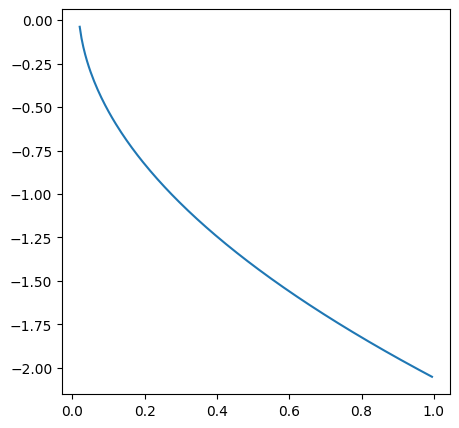

In [24]:
f =  0.1083693699735 - 5.0e-14*sp.sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)
valores = np.arange(0,1, 0.005)
f_np = sp.lambdify(V, f, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np(valores))
plt.show()

<lambdifygenerated-5>:2: RuntimeWarning: invalid value encountered in sqrt
  return 5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735


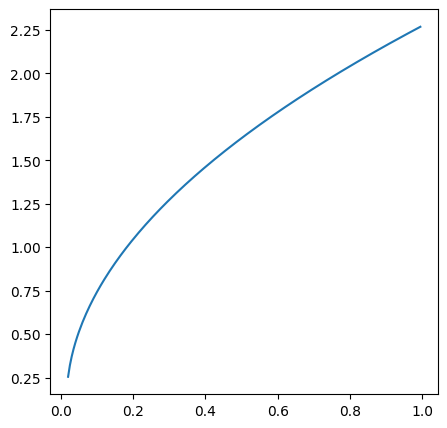

In [28]:
f2 = p2 = 5.0e-14*sp.sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735
f_np2 = sp.lambdify(V, f2, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np2(valores))
plt.show()